In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [2]:
from functools import partial

from IPython.display import display, Markdown, Image
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape, mase

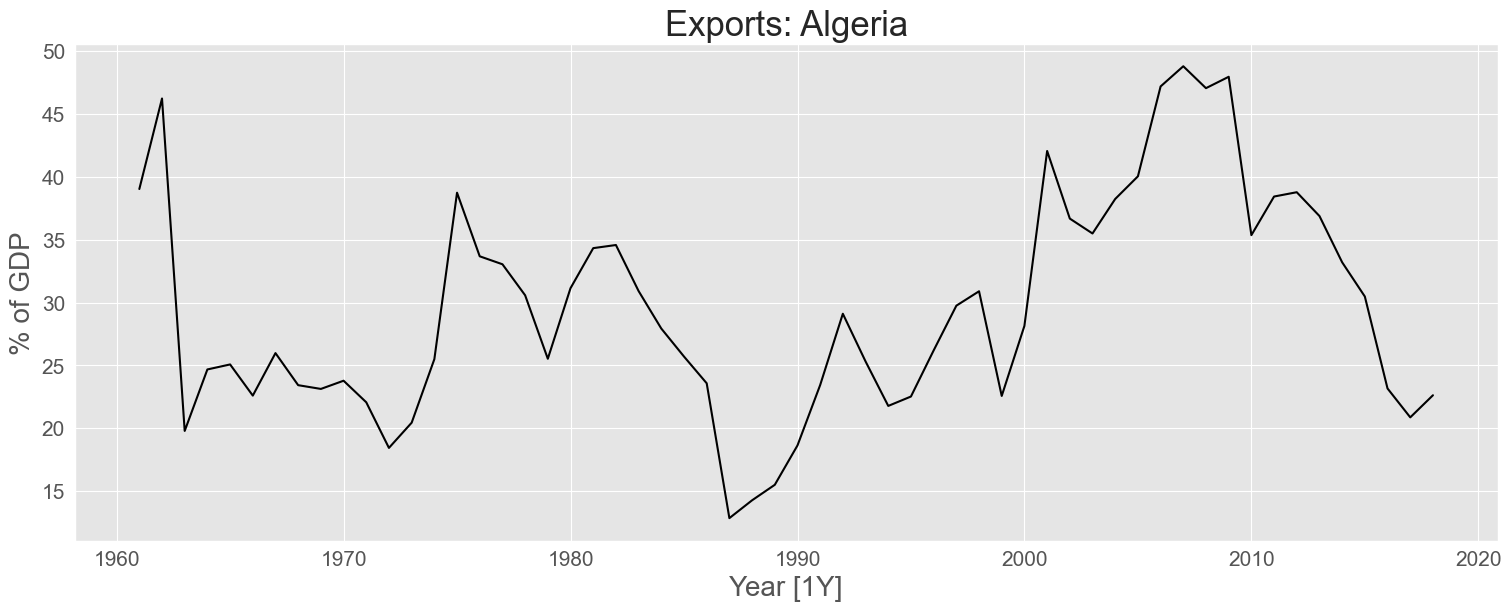

In [3]:
algeria_economy = pd.read_csv("algeria_exports.csv",
    parse_dates=["ds"])
plt.rcParams["figure.figsize"] = (8, 4.3)
plot_series(algeria_economy,
    xlabel="Year [1Y]", ylabel="% of GDP", title="Exports: Algeria")

In [4]:
sf = StatsForecast(freq="Y",
    models=[AutoETS(model="ANN", alias="SES")])

fc = sf.forecast(df=algeria_economy, h=5, level=[80, 95], fitted=True)
fc.head()

,unique_id,ds,SES,SES-lo-95,SES-lo-80,SES-hi-80,SES-hi-95
0,Algeria,2018-12-31,22.442,10.523,14.648,30.235,34.361
1,Algeria,2019-12-31,22.442,6.875,12.263,32.620,38.009
2,Algeria,2020-12-31,22.442,3.933,10.339,34.544,40.951
3,Algeria,2021-12-31,22.442,1.398,8.682,36.202,43.486
4,Algeria,2022-12-31,22.442,-0.863,7.204,37.680,45.746


In [5]:
fitted_vals = sf.forecast_fitted_values()
fitted_vals.head()

,unique_id,ds,y,SES,SES-lo-95,SES-lo-80,SES-hi-80,SES-hi-95
0,Algeria,1960-12-31,39.043,39.530,27.720,31.808,47.252,51.340
1,Algeria,1961-12-31,46.245,39.121,27.311,31.399,46.843,50.931
2,Algeria,1962-12-31,19.794,45.105,33.295,37.383,52.828,56.916
3,Algeria,1963-12-31,24.685,23.842,12.031,16.119,31.564,35.652
4,Algeria,1964-12-31,25.084,24.550,12.740,16.828,32.272,36.360


In [6]:
# Save model fit(s)
sf.fit(algeria_economy)
# Save model fit(s) and return forecasts
fc = sf.fit_predict(df=algeria_economy, h=5, level=[80, 95])
params = sf.fitted_[0, 0].model_["fit"].x
alpha, level_0 = np.round(params, 4)

In [7]:
ses = AutoETS(model="ANN", alias="SES")
ses.fit(y=algeria_economy["y"].values)
params = ses.model_["fit"].x
alpha, level_0 = np.round(params, 4)
print("Optimal parameters:")
print("alpha:", alpha)
print("Initial level:", level_0)

Optimal parameters:
alpha: 0.8401
Initial level: 39.53


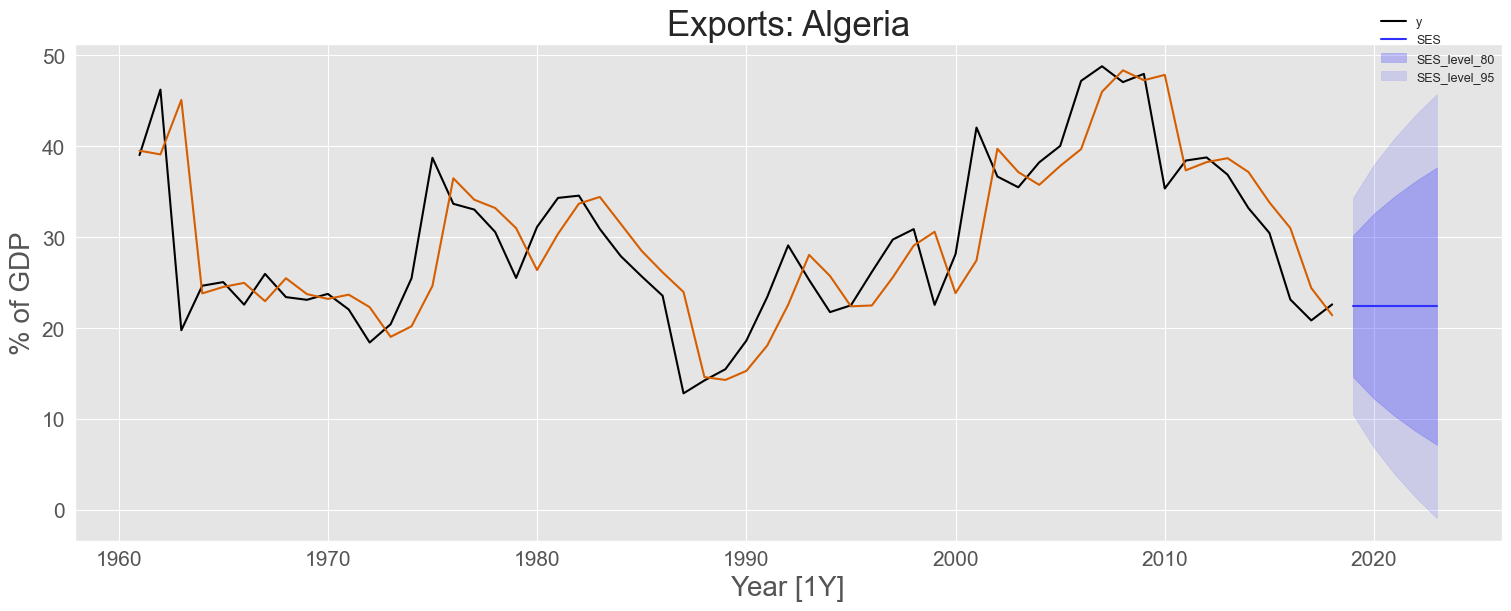

In [8]:
fig = plot_series(algeria_economy, fc, level=[80, 95],
    xlabel="Year [1Y]", ylabel="% of GDP", title="Exports: Algeria",
    palette="black_and_blue", rm_legend=False)
fig.axes[0].plot("ds", "SES", data=fitted_vals, color="#D55E00")
fig

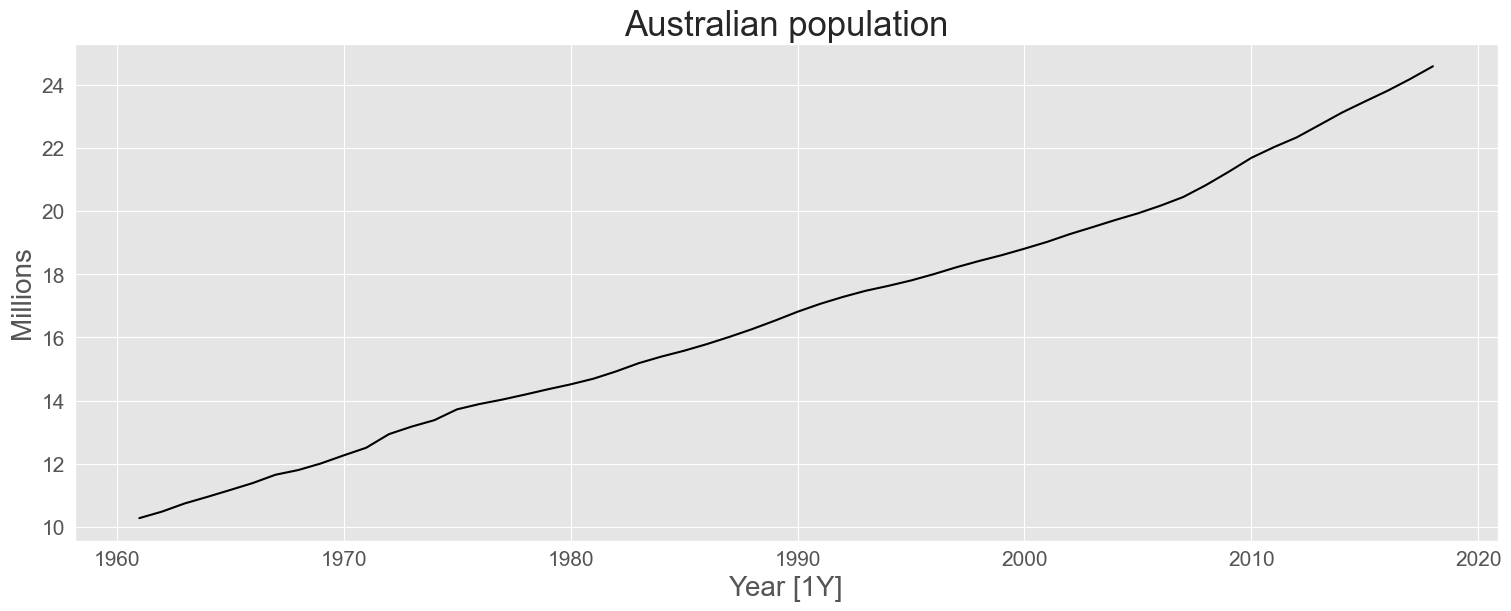

In [9]:
aus_economy = (
    pd.read_csv("aus_economy.csv", parse_dates=["ds"])
    .assign(y=lambda x: x["y"] / 1e6)
)
plot_series(aus_economy, xlabel="Year [1Y]", ylabel="Millions",
    title="Australian population")

In [10]:
sf = StatsForecast(models=[AutoETS(model="AAN", alias="Holt")], freq="A")
fc = sf.fit_predict(df=aus_economy, h=10)

In [11]:
holt = sf.fitted_[0, 0]
params = np.round(holt.model_["fit"].x, 4)
print("Optimal parameters:")
print("alpha:", params[0])
print("beta:", params[1])
print("Initial level:", params[2])
print("Initial trend:", params[3])

Optimal parameters:
alpha: 0.9999
beta: 0.2001
Initial level: 10.0509
Initial trend: 0.2264


In [12]:
sf = StatsForecast(
  models=[
    AutoETS(model="AAN", alias="Holt"),
    AutoETS(model="AAN", alias="Damped Holt's method",
      damped=True, phi=0.9),
  ],
  freq="Y",
)
fc = sf.forecast(df=aus_economy, h=15)

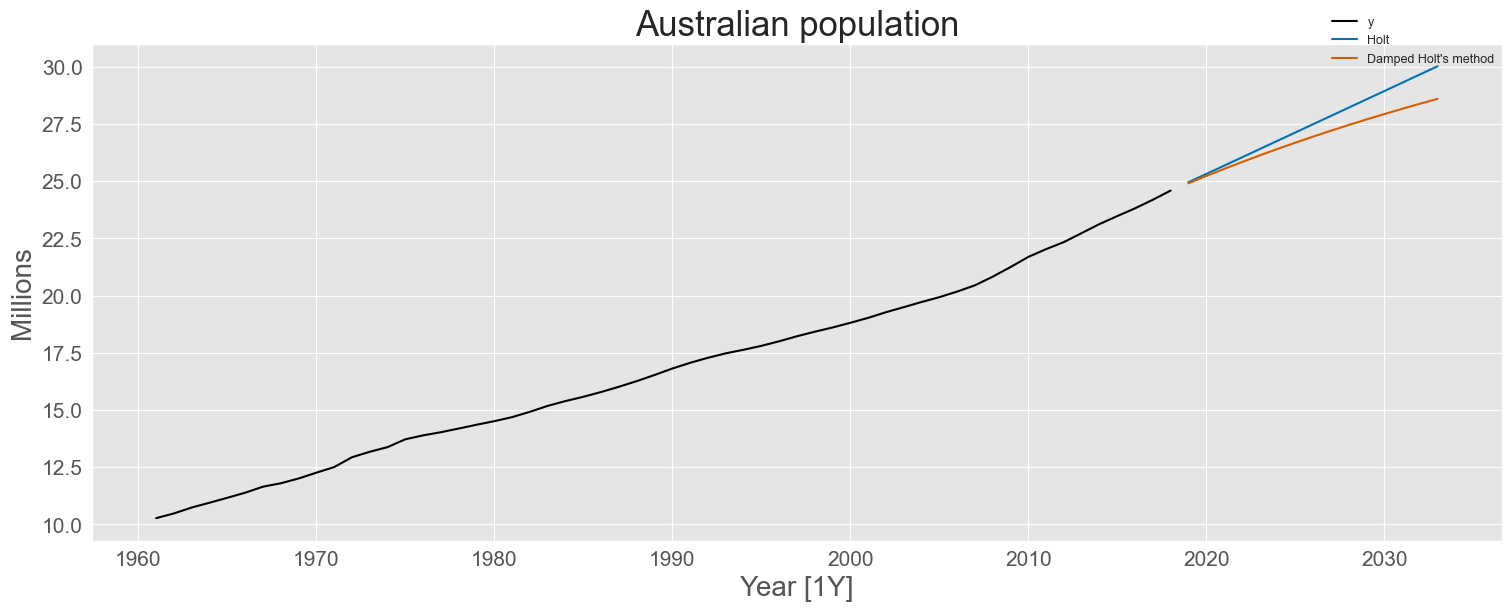

In [13]:
plot_series(aus_economy, fc,
  xlabel="Year [1Y]", ylabel="Millions", title="Australian population",
  palette="black_and_2color", rm_legend=False)

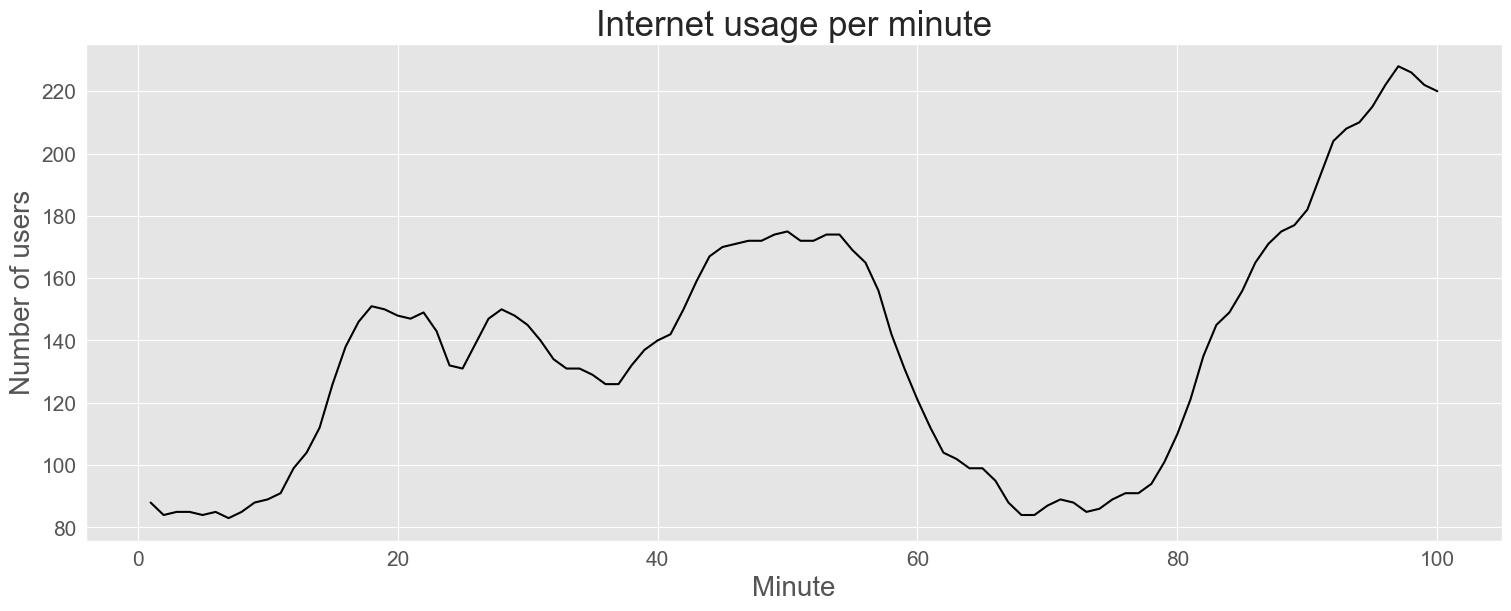

In [14]:
www_usage = pd.read_csv("www_usage.csv")
plot_series(www_usage, xlabel="Minute", ylabel="Number of users",
  title="Internet usage per minute")

In [15]:
from utilsforecast.losses import mape as _mape
def mape(df, models, id_col = "unique_id", target_col = "y"):
    """MAPE scaled to percentage."""
    df_mape = _mape(df, models, id_col=id_col, target_col=target_col)
    df_mape.loc[:, df_mape.select_dtypes(include='number').columns] *= 100
    return df_mape

sf = StatsForecast(
    models=[
        AutoETS(model="ANN", alias="SES"),
        AutoETS(model="AAN", alias="Holt"),
        AutoETS(model="AAN", damped=True, phi=0.9, alias="Damped"),
    ],
    freq=1,
)
cv = sf.cross_validation(df=www_usage, h=1, n_windows=90, step_size=1)
result_df = evaluate(
    cv.drop("cutoff", axis=1),
    metrics=[rmse, mae, mape, partial(mase, seasonality=1)],
    train_df=www_usage,
)
(result_df.drop(columns="unique_id")
    .set_index("metric").T
    .rename(columns=str.upper))

metric,RMSE,MAE,MAPE,MASE
SES,6.072,4.849,3.588,1.072
Holt,5.087,4.181,3.164,0.924
Damped,5.038,4.058,3.059,0.897


In [16]:
sf = StatsForecast(
    models=[AutoETS(model="AAN", damped=True, alias="Damped")],
    freq=1,
)
sf.fit(www_usage)
params = np.round(sf.fitted_[0, 0].model_["fit"].x, 4)
print("Optimal parameters:")
print("Damped alpha:", params[0])
print("Damped beta:", params[1])
print("Damped phi:", params[2])
print("Initial level:", params[3])
print("Initial trend:", params[4])

Optimal parameters:
Damped alpha: 0.9999
Damped beta: 0.2
Damped phi: 0.9078
Initial level: 88.823
Initial trend: -0.9607


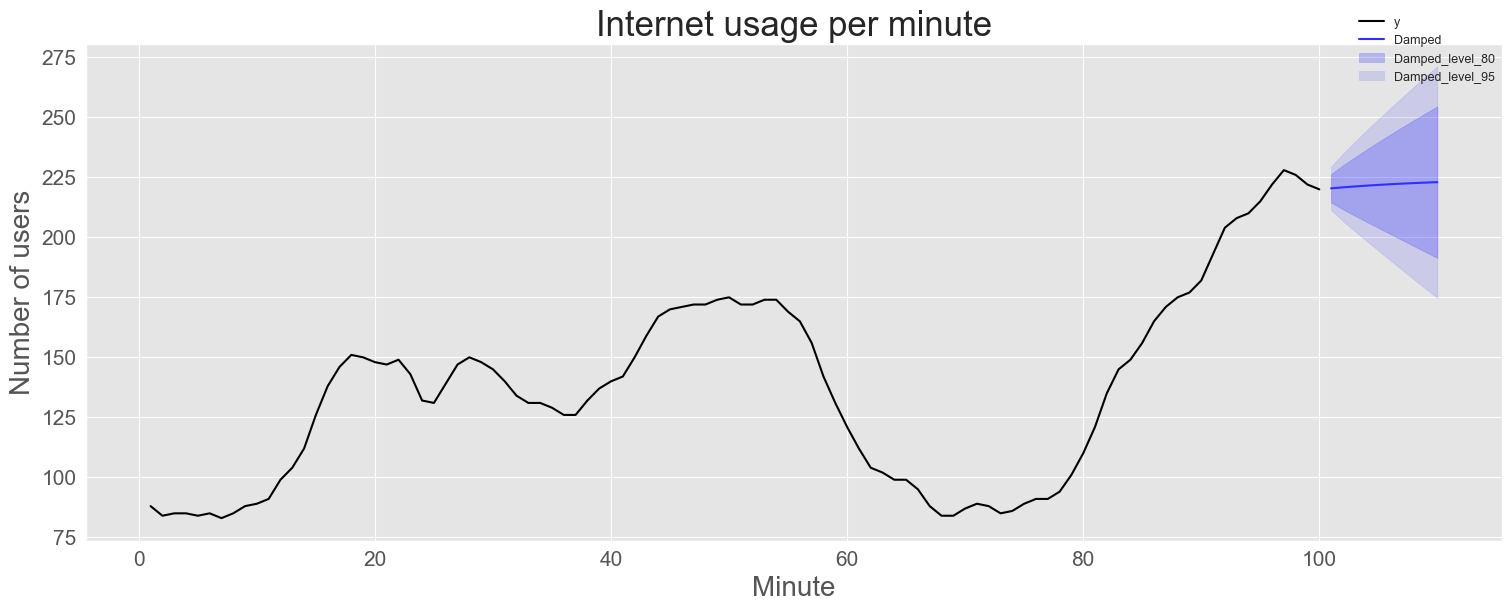

In [17]:
level = [80, 95]
fc = sf.predict(h=10, level=level)
plot_series(www_usage, fc, level=level,
    xlabel="Minute", ylabel="Number of users",
    title="Internet usage per minute",
    palette="black_and_blue", rm_legend=False)

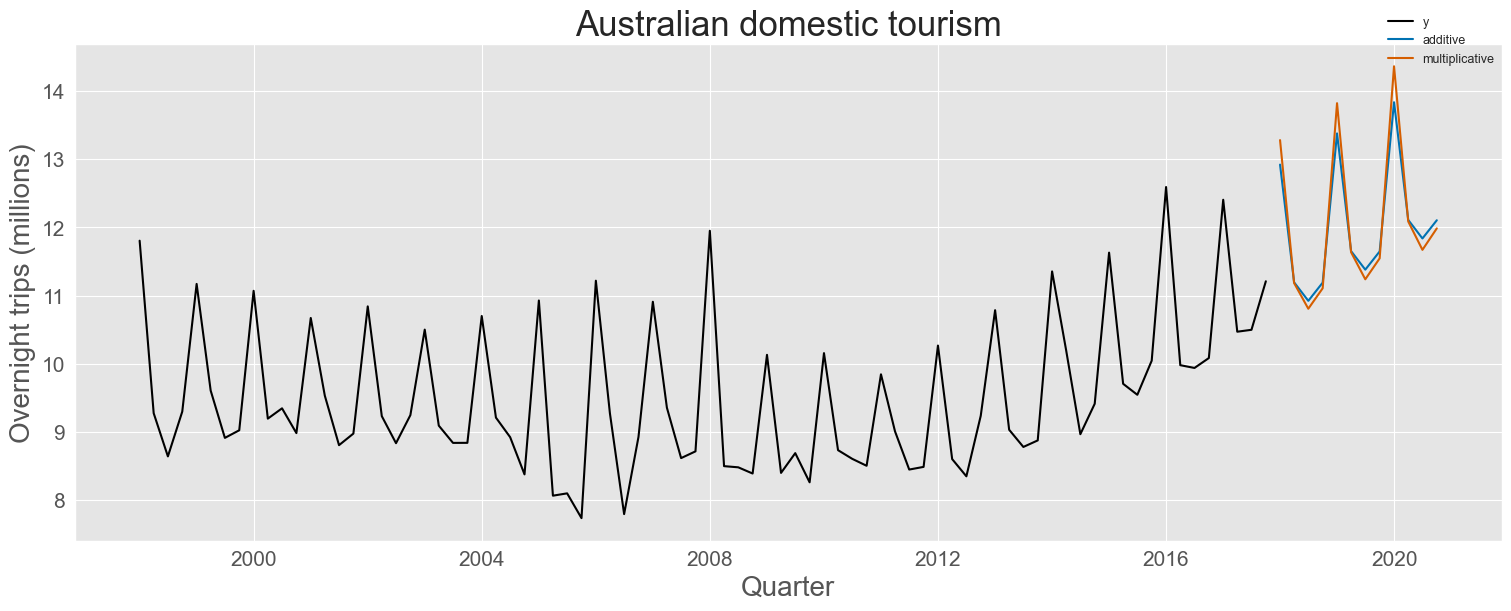

In [18]:
tourism = pd.read_csv("tourism.csv", parse_dates=["ds"])
aus_holidays = (
    tourism.loc[lambda x: x["Purpose"] == "Holiday"]
    .rename(columns={"Purpose": "unique_id"})
    .groupby(["unique_id", "ds"])
    ["y"].sum().div(1e3)
    .reset_index()
)
sf = StatsForecast(
    models=[
        AutoETS(season_length=4, model="AAA", alias="additive"),
        AutoETS(season_length=4, model="MAM", alias="multiplicative"),
    ],
    freq="Q",
)
fc = sf.forecast(df=aus_holidays, h=12, fitted=True)
plot_series(aus_holidays, fc,
    xlabel="Quarter", ylabel="Overnight trips (millions)",
    title="Australian domestic tourism",
    palette="black_and_2color", rm_legend=False)

In [19]:
from statsforecast.models import HoltWinters
HoltWinters(season_length=4, error_type="A", alias="additive")
HoltWinters(season_length=4, error_type="M", alias="multiplicative")

multiplicative

In [20]:
fitted_vals = sf.forecast_fitted_values()
evaluate(fitted_vals, metrics=[rmse])

,unique_id,metric,additive,multiplicative
0,Holiday,rmse,0.412,0.411


In [21]:
sf.fit(aus_holidays)
for model in sf.fitted_[0]:
    print(model)
    # parameters: [alpha, beta, gamma, phi, l0, (b0 if trend), s1, ..., sm]
    par = model.model_["par"]
    components = model.model_["components"]
    trendtype = components[1]
    alpha, beta, gamma = np.round(par[:3], 4)
    level_0 = np.round(par[4], 4)
    seasonal_start = 4 + 1 + (1 if trendtype != "N" else 0)
    seasonal = np.round(par[seasonal_start:], 4)
    print("  Optimal parameters:")
    print("  alpha:", alpha)
    print("  beta:", beta)
    print("  gamma:", gamma)
    print("  Initial level:", level_0)
    print("  Initial seasonal components:", seasonal)
    print("  Sum of seasonal components:", seasonal.sum())

additive
  Optimal parameters:
  alpha: 0.2325
  beta: 0.03
  gamma: 0.0001
  Initial level: 9.8372
  Initial seasonal components: [-0.5386 -0.6916 -0.3051  1.5353]
  Sum of seasonal components: 2.220446049250313e-16
multiplicative
  Optimal parameters:
  alpha: 0.2384
  beta: 0.0274
  gamma: 0.0008
  Initial level: 9.8198
  Initial seasonal components: [0.9429 0.9266 0.9686 1.1619]
  Sum of seasonal components: 4.0


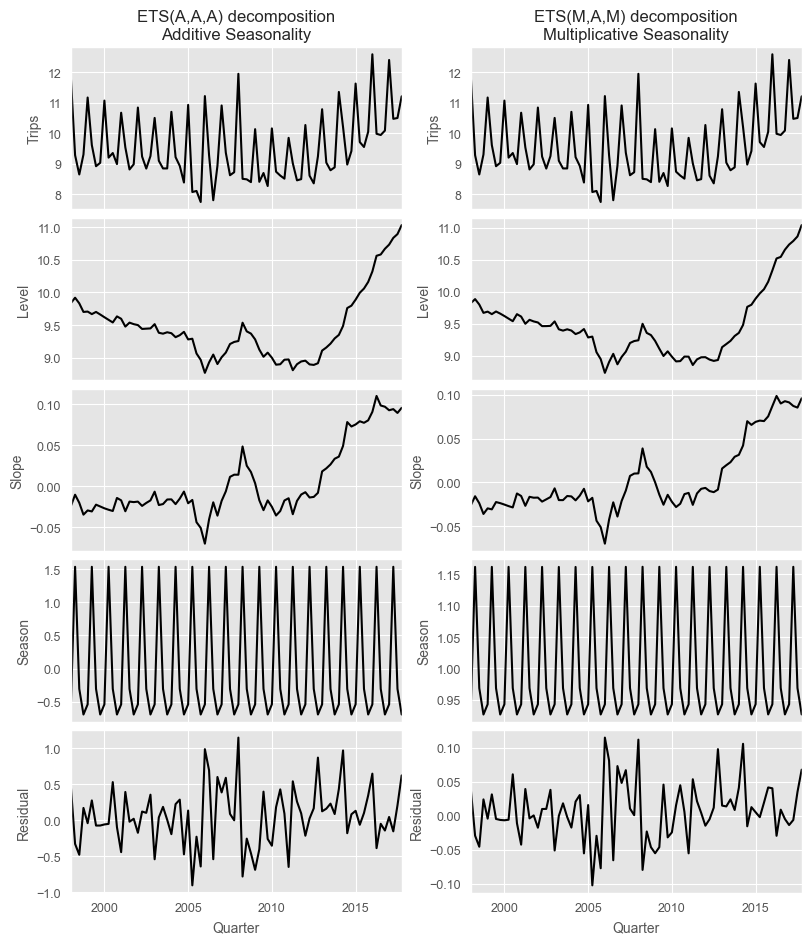

In [22]:
titles = [
    "ETS(A,A,A) decomposition\nAdditive Seasonality",
    "ETS(M,A,M) decomposition\nMultiplicative Seasonality",
]
states = ["Level", "Slope", "Season"]

fig, all_axes = plt.subplots(5, 2, figsize=(8, 8*14/12), sharex=True)
for (axes, title, model) in zip(all_axes.T, titles, sf.fitted_[0]):
    states = model.model_["states"]
    df = pd.DataFrame({
        "Trips": aus_holidays["y"].to_numpy(),
        "Level": states[:, 0][:-1],
        "Slope": states[:, 1][:-1],
        "Season": states[:, 2][:-1],
        "Residual": model.model_["residuals"],
        "Quarter": aus_holidays["ds"].to_numpy(),
    }).set_index("Quarter")
    for (ax, column) in zip(axes, df.columns):
        df[column].plot(ax=ax, ylabel=column)
    axes[0].set(title=title)

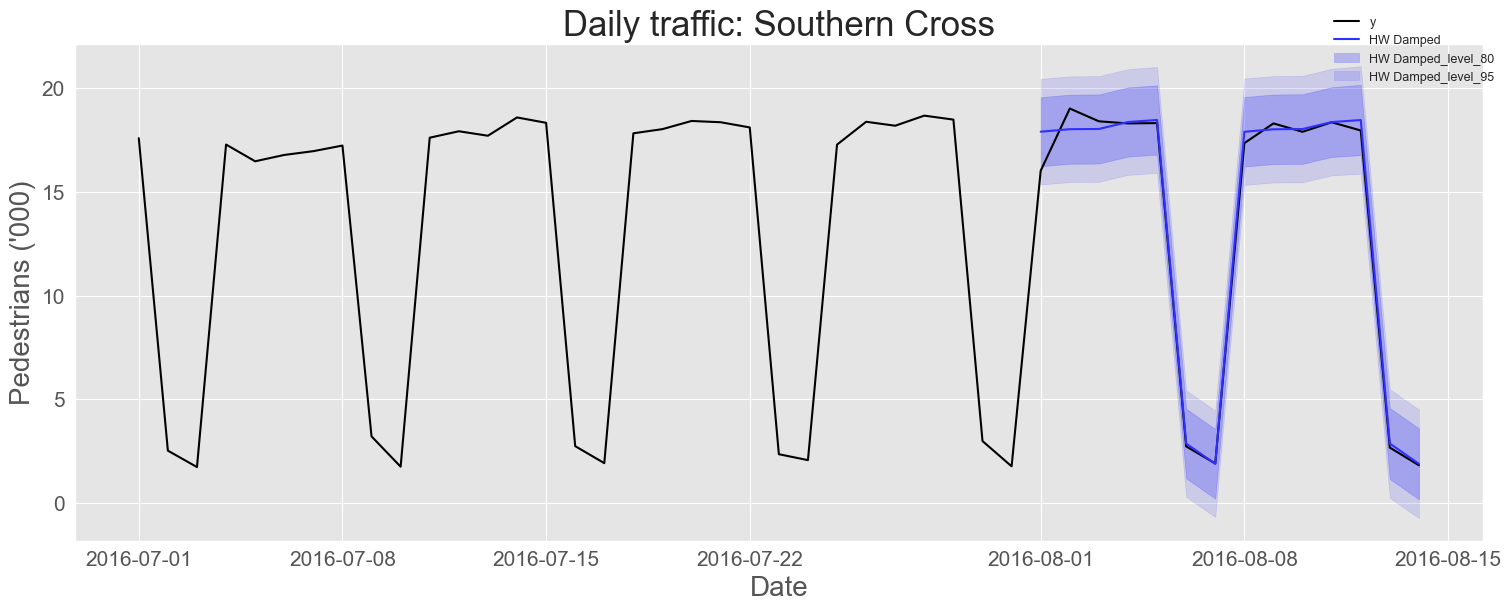

In [23]:
sth_cross_ped = (
    pd.read_csv("pedestrian.csv", parse_dates=["ds"])
    .loc[lambda x:
        (x["unique_id"] == "Southern Cross Station")
        & (x["ds"].between("2016-07", "2016-08-14"))
    ]
    .groupby(["unique_id", "ds"])
    ["y"].sum().div(1e3)
    .reset_index()
)
train = sth_cross_ped.loc[lambda x: x["ds"] < "2016-08"]
sf = StatsForecast(
    models=[AutoETS(season_length=7, model="MAM",
        damped=True, alias="HW Damped")],
    freq="D",
)
level = [80, 95]
fc = sf.forecast(df=train, h=14, level=level)
plot_series(sth_cross_ped, fc, level=level,
    xlabel="Date", ylabel="Pedestrians ('000)",
    title="Daily traffic: Southern Cross",
    palette="black_and_blue", rm_legend=False)

In [24]:
sf = StatsForecast(models=[AutoETS(season_length=4)], freq="Q")
sf.fit(aus_holidays)
autoets = sf.fitted_[0, 0]
model = autoets.model_
model["method"]

'ETS(M,N,M)'

In [25]:
params = np.round(autoets.model_["fit"].x, 4)
print("Optimal parameters:")
print("alpha:", params[0])
print("gamma:", params[1])
print("Initial level for series:", params[2])
print("Initial seasonal components:", params[3:])

Optimal parameters:
alpha: 0.3612
gamma: 0.0001
Initial level for series: 9.7878
Initial seasonal components: [0.9432 0.9268 0.9683]


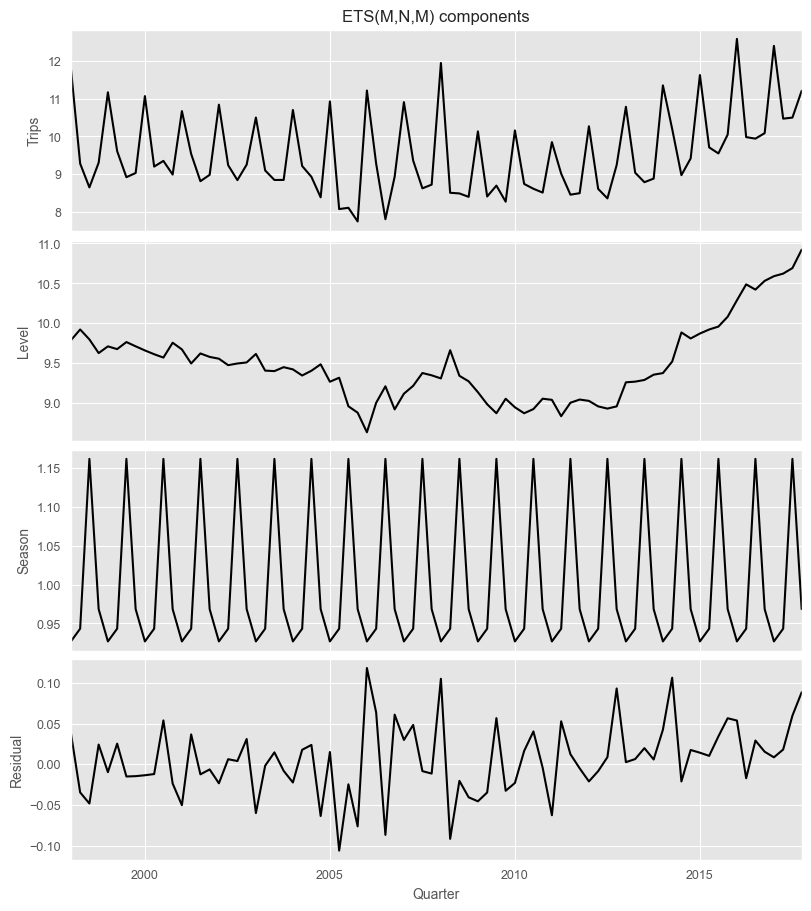

In [26]:
states = model["states"]
df = pd.DataFrame({
    "Trips": aus_holidays["y"].to_numpy(),
    "Level": states[:, 0][:-1],
    "Season": states[:, 2][:-1],
    "Residual": model["residuals"],
    "Quarter": aus_holidays["ds"].to_numpy(),
}).set_index("Quarter")
fig, axes = plt.subplots(4, 1, figsize=(8, 9), sharex=True)
for (ax, column) in zip(axes, df.columns):
    df[column].plot(ax=ax, ylabel=column)
axes[0].set(title="ETS(M,N,M) components")
plt.show()

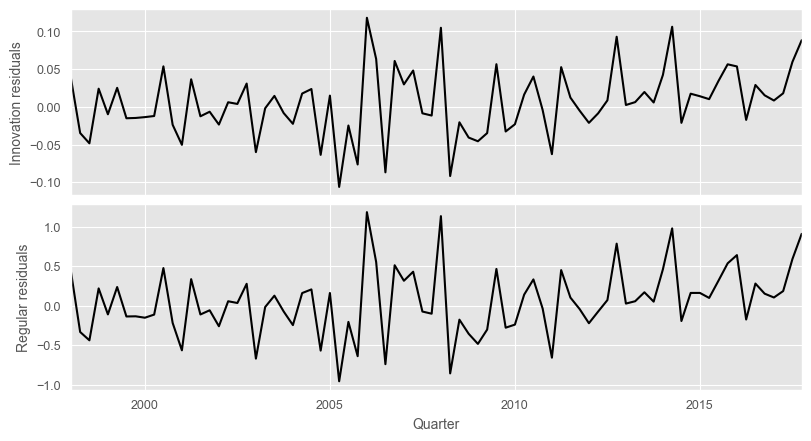

In [27]:
df = pd.DataFrame({
    "Innovation residuals": autoets.model_["residuals"],
    "Regular residuals": autoets.model_["actual_residuals"],
    "Quarter": aus_holidays["ds"].to_numpy(),
}).set_index("Quarter")
fig, axes = plt.subplots(2, 1, sharex=True)
for (ax, column) in zip(axes, df.columns):
    df[column].plot(ax=ax, ylabel=column)
plt.show()

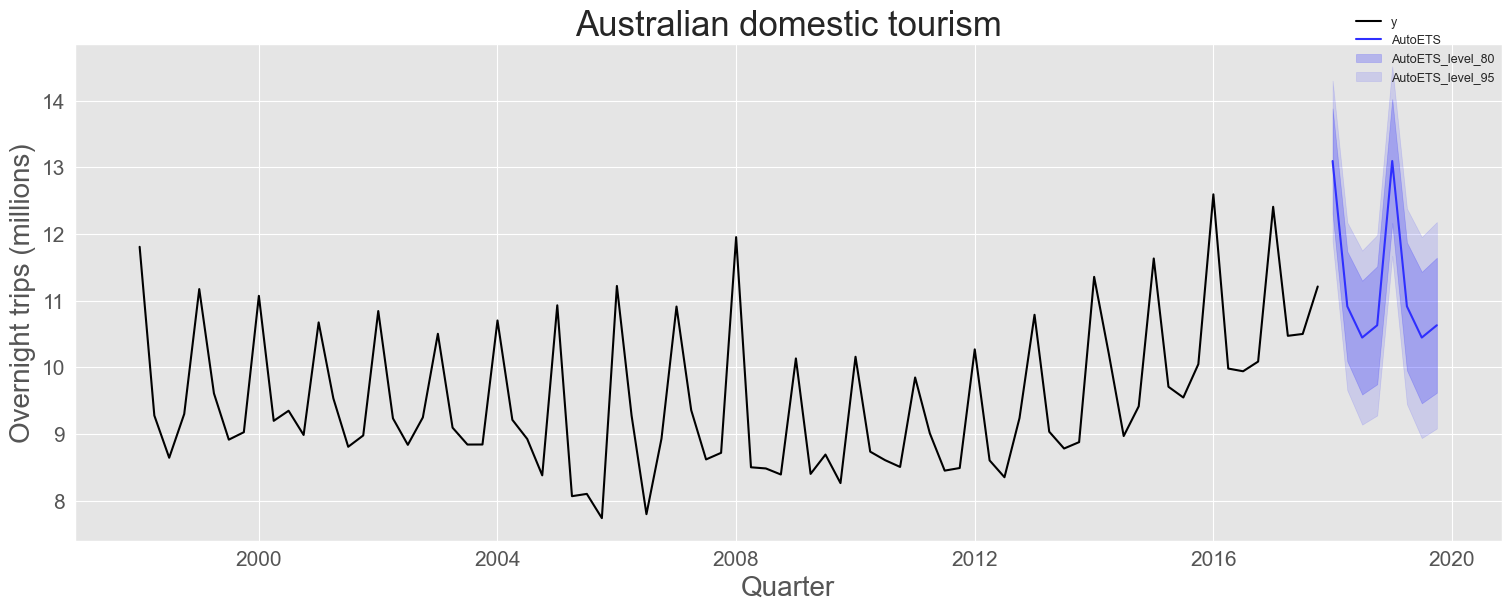

In [29]:
sf = StatsForecast(models=[AutoETS(season_length=4)], freq="Q")
fc = sf.forecast(df=aus_holidays, h=8, level=[80, 95])
plot_series(aus_holidays, fc, level=[80, 95],
    xlabel="Quarter", ylabel="Overnight trips (millions)",
    title="Australian domestic tourism",
    palette="black_and_blue", rm_legend=False)